# Fig: Infotaxis vs MAP, pfa sweep: pmax_th=0.95

Reference: 
- `fig_S5_infotaxis_MAP_cmp_pm0.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_success
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  991    right:  536
Mean:    left: 10.329  right: 14.252
Median:  left: 10.000  right: 14.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  985    right:  534
Mean:    left: 12.236  right: 17.715
Median:  left: 12.000  right: 17.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  981    right:  553
Mean:    left: 13.502  right: 20.146
Median:  left: 13.000  right: 20.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  973    right:  495
Mean:    left: 18.317  right: 27.440
Median:  left: 18.000  right: 27.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


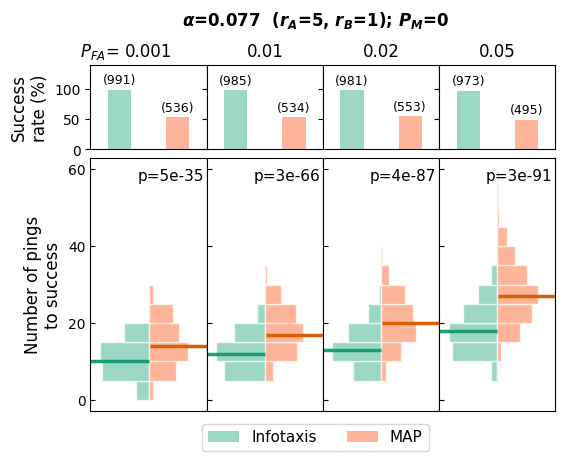

Samples: left:  985    right:  309
Mean:    left: 7.499  right: 10.796
Median:  left: 7.000  right: 11.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  972    right:  340
Mean:    left: 10.417  right: 15.500
Median:  left: 10.000  right: 15.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  972    right:  314
Mean:    left: 13.150  right: 19.691
Median:  left: 13.000  right: 19.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  957    right:  301
Mean:    left: 23.031  right: 34.897
Median:  left: 21.000  right: 34.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


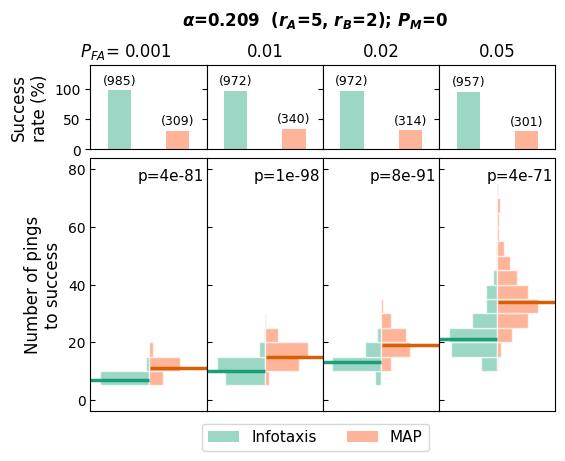

Samples: left:  989    right:  566
Mean:    left: 28.655  right: 37.640
Median:  left: 27.000  right: 34.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  987    right:  531
Mean:    left: 32.262  right: 42.137
Median:  left: 31.000  right: 37.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  970    right:  521
Mean:    left: 36.315  right: 46.236
Median:  left: 34.000  right: 42.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  965    right:  512
Mean:    left: 45.466  right: 63.018
Median:  left: 44.000  right: 60.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


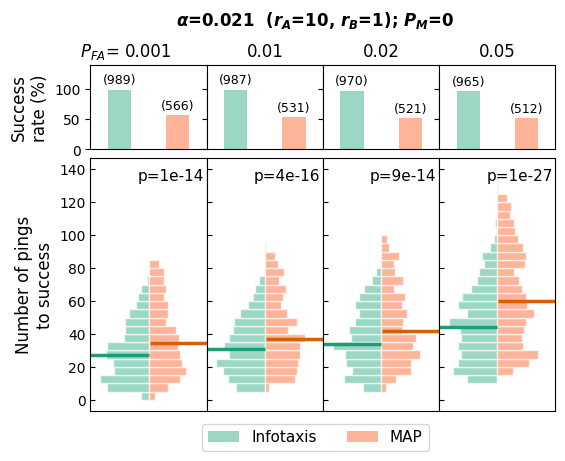

Samples: left:  976    right:  324
Mean:    left: 14.984  right: 20.012
Median:  left: 15.000  right: 19.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  970    right:  315
Mean:    left: 19.624  right: 28.438
Median:  left: 19.000  right: 28.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  960    right:  268
Mean:    left: 25.167  right: 36.134
Median:  left: 24.000  right: 35.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  965    right:  298
Mean:    left: 47.599  right: 67.846
Median:  left: 49.000  right: 69.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


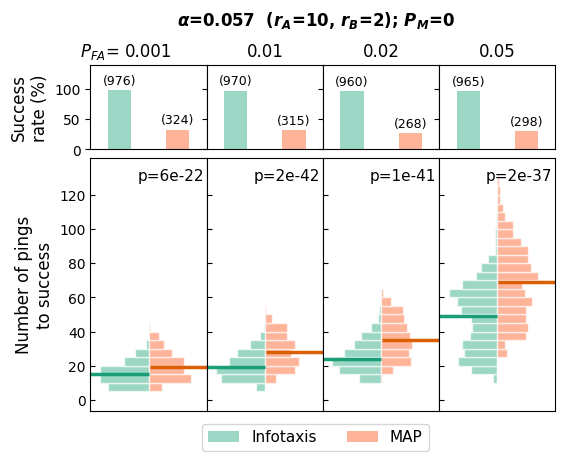

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pfa_all = [0.001, 0.01, 0.02, 0.05]
pm = 0

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260608_pfa_sweep_infotaxis_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260608_pfa_sweep_MAP_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pfa in pfa_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="sweep",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm, pfa=pfa
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="sweep",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm, pfa=pfa
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)


        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pfa_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Infotaxis", y_str="MAP",
            comparison_type="pfa_sweep",
            stats_type="less",
            # title_str_additional="Mismatched (agent higher)",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=1,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_pfa_sweep_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )